In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris # For a standard pre-loaded dataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print(tf.__version__)

# data loading -> data preparation -> model preparation -> model compile, training -> model evaluation

# --- Step 1: Data Loading (Iris Dataset) ---
print("\n--- Step 1: Data Loading (Iris Dataset) ---")
iris = load_iris()
X, y = iris.data, iris.target

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


2.20.0

--- Step 1: Data Loading (Iris Dataset) ---


In [ ]:
# --- Step 2: Data Analysis ---
print("\n--- Step 2: Data Analysis ---")
#150 samples, 80% data as training data and 4 features
print(f"Shape of training features (X_train): {X_train.shape}")
print(f"Shape of training labels (y_train): {y_train.shape}")
print(f"Shape of test features (X_test): {X_test.shape}")
print(f"Shape of test labels (y_test): {y_test.shape}")

print("\nFeature names:")
print(iris.feature_names)

print("\nFirst 5 rows of training features:")
print(pd.DataFrame(X_train, columns=iris.feature_names).head())
print("\nSummary statistics of training features:")
print(pd.DataFrame(X_train, columns=iris.feature_names).describe())

print("\nDistribution of target labels (y_train):")
print(pd.Series(y_train).value_counts())


--- Step 2: Data Analysis ---
Shape of training features (X_train): (120, 4)
Shape of training labels (y_train): (120,)
Shape of test features (X_test): (30, 4)
Shape of test labels (y_test): (30,)

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

First 5 rows of training features:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                4.4               2.9                1.4               0.2
1                4.9               2.5                4.5               1.7
2                6.8               2.8                4.8               1.4
3                4.9               3.1                1.5               0.1
4                5.5               2.5                4.0               1.3

Summary statistics of training features:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         120.000000        120.000000          120.00000   
mean            5.841667          3.04

In [ ]:
# --- Step 3: Data Preprocessing (Scaling Numerical Features) ---
print("\n--- Step 3: Data Preprocessing (Scaling Numerical Features) ---")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("First 5 rows of scaled training features:")
print(pd.DataFrame(X_train_scaled, columns=iris.feature_names).head())
print("Summary statistics of scaled training features:")
print(pd.DataFrame(X_train_scaled, columns=iris.feature_names).describe())

# Determine the number of classes for the output layer
num_classes = len(np.unique(y_train))
print(f"Number of output classes: {num_classes}")


--- Step 3: Data Preprocessing (Scaling Numerical Features) ---
First 5 rows of scaled training features:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0          -1.721568         -0.332101          -1.345722         -1.323276
1          -1.124492         -1.227655           0.414505          0.651763
2           1.144395         -0.555990           0.584850          0.256755
3          -1.124492          0.115676          -1.288941         -1.454945
4          -0.408002         -1.227655           0.130598          0.125086
Summary statistics of scaled training features:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count       1.200000e+02      1.200000e+02       1.200000e+02   
mean       -1.184238e-15     -1.998401e-15       4.958996e-16   
std         1.004193e+00      1.004193e+00       1.004193e+00   
min        -1.840983e+00     -2.347097e+00      -1.516067e+00   
25%        -8.856620e-01     -5.559895e-01      -1.232159e+00   

In [ ]:
# --- Step 4: Model Building ---
# https://keras.io/2/api/layers/regularizers/
print("\n--- Step 4: Model Building ---")
model = keras.Sequential([
    keras.layers.Dense (32, activation='relu', input_shape=(X_train_scaled.shape[1],)), # Input layer
    keras.layers.Dense(16, activation='tanh',kernel_regularizer='l2'),
    keras.layers.Dropout(0.2),                                                         # Dropout layer
    keras.layers.Dense(8, activation='relu'),                                         # Hidden layer
    keras.layers.Dense(num_classes, activation='softmax')                             # Output layer for multi-class classification
])

model.summary()


--- Step 4: Model Building ---


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 851 (3.32 KB)

 Trainable params: 851 (3.32 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# --- Step 5: Model Compilation ---
print("\n--- Step 5: Model Compilation ---")
# For multi-class classification with integer labels, use 'sparse_categorical_crossentropy'
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.005), #'adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


--- Step 5: Model Compilation ---


In [ ]:
# --- Step 6: Model Training ---
print("\n--- Step 6: Model Training ---")
# 150 data points -> training data -> 120 ; 80% is training, 20% for validation;
# 96 inputs - batchsize of 8 - 12 iterations will make 1 epoch
history = model.fit(X_train_scaled, y_train, epochs=30, batch_size=8, validation_split=0.2, verbose=1)




--- Step 6: Model Training ---
Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5729 - loss: 0.8868 - val_accuracy: 0.6667 - val_loss: 0.5902
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8333 - loss: 0.4789 - val_accuracy: 0.7917 - val_loss: 0.4506
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8958 - loss: 0.3623 - val_accuracy: 0.8750 - val_loss: 0.3475
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8646 - loss: 0.3239 - val_accuracy: 0.9167 - val_loss: 0.2736
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8958 - loss: 0.2875 - val_accuracy: 0.9167 - val_loss: 0.2649
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9271 - loss: 0.2239 - val_accuracy: 0.9583 - val_loss: 0.1959
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9062 - loss: 0.1982 - val_accuracy: 0.9583 - val_loss: 0.1685
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9271 - loss: 0.1799 -

In [ ]:
model.get_weights()

[array([[ 0.28142014, -0.19177312,  0.26912278,  0.073802  ,  0.34569776,
         -0.2326929 , -0.4866541 ,  0.32617295, -0.02246761, -0.19509271,
         -0.03359254, -0.30698472,  0.30448037,  0.38635606, -0.13468383,
          0.20763782,  0.28507373,  0.33600795,  0.44218925,  0.42501307,
         -0.2917187 ,  0.24751525,  0.15372278,  0.19820206, -0.14770731,
         -0.01891524, -0.22360663,  0.02937046, -0.17250887,  0.05621959,
          0.2963201 , -0.13376863],
        [-0.28668153,  0.16908546, -0.01123525, -0.32486805,  0.22497652,
          0.536788  ,  0.3357584 , -0.3861482 , -0.11620381, -0.27235422,
         -0.0801966 , -0.2105995 ,  0.3630005 ,  0.2801425 ,  0.1439496 ,
         -0.22737125, -0.36338586, -0.04293201, -0.05618577,  0.10356317,
          0.43499434, -0.31288162, -0.38374668, -0.02836398, -0.06738779,
          0.16291796, -0.20832786, -0.27606916, -0.4477013 , -0.0835994 ,
         -0.3845835 , -0.44560665],
        [ 0.0609809 , -0.26635844,  0.57

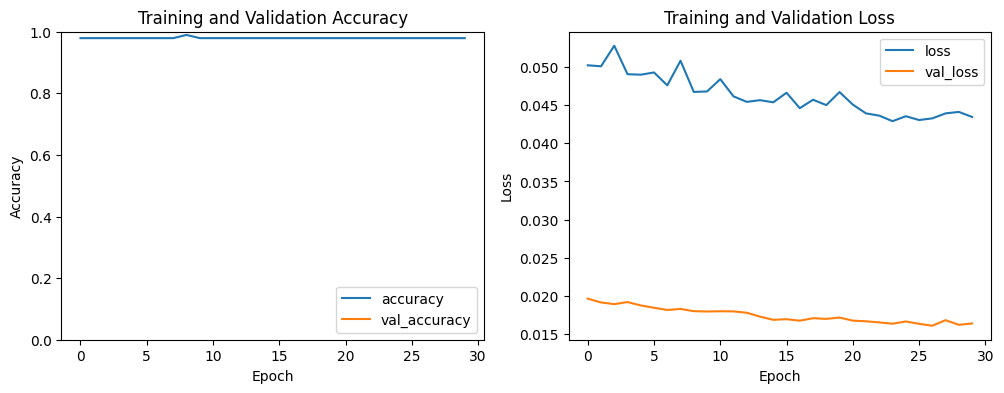

In [ ]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# --- Step 7: Model Evaluation ---
print("\n--- Step 7: Model Evaluation ---")
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=1)
print(f'\nTest loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')


--- Step 7: Model Evaluation ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9667 - loss: 0.0839

Test loss: 0.0839
Test accuracy: 0.9667


In [ ]:
# --- Step 8: Inference ---
print("\n--- Step 8: Inference ---")
# Make predictions on the first 5 test samples
predictions = model.predict(X_test_scaled[:5])
predicted_classes = np.argmax(predictions, axis=1)

print("\nPredictions for the first 5 test samples:")
for i in range(5):
    print(f"Sample {i+1}: Predicted Probabilities = {predictions[i]}, Predicted Class = {iris.target_names[predicted_classes[i]]} ({predicted_classes[i]}), Actual Class = {iris.target_names[y_test[i]]} ({y_test[i]})")



--- Step 8: Inference ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

Predictions for the first 5 test samples:
Sample 1: Predicted Probabilities = [9.9958616e-01 3.9585025e-04 1.7947519e-05], Predicted Class = setosa (0), Actual Class = setosa (0)
Sample 2: Predicted Probabilities = [0.00231795 0.23627618 0.7614059 ], Predicted Class = virginica (2), Actual Class = virginica (2)
Sample 3: Predicted Probabilities = [6.5415720e-03 9.9294347e-01 5.1490607e-04], Predicted Class = versicolor (1), Actual Class = versicolor (1)
Sample 4: Predicted Probabilities = [2.2882251e-03 9.9738294e-01 3.2890931e-04], Predicted Class = versicolor (1), Actual Class = versicolor (1)
Sample 5: Predicted Probabilities = [9.9968398e-01 3.0076399e-04 1.5201454e-05], Predicted Class = setosa (0), Actual Class = setosa (0)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
# 1. Define the early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',          # Metric to monitor
    patience=10,                  # Number of epochs to wait for improvement
    restore_best_weights=True,   # Roll back to the best model weights
    mode='min'                   # Stop when the metric stops minimizing
)

# 2. Pass the callback into the model.fit() function
model.fit(X_train_scaled, y_train, epochs=100, batch_size=8, validation_split=0.2, verbose=1,callbacks=[early_stop]       )
#model.fit(    X_train, y_train,     epochs=100,     validation_data=(X_val, y_val),     callbacks=[early_stop]       # Early stopping is supplied as a list
#)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9896 - loss: 0.0384 - val_accuracy: 1.0000 - val_loss: 0.0176
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9792 - loss: 0.0396 - val_accuracy: 1.0000 - val_loss: 0.0198
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9688 - loss: 0.0523 - val_accuracy: 1.0000 - val_loss: 0.0121
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9688 - loss: 0.0494 - val_accuracy: 1.0000 - val_loss: 0.0136
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9792 - loss: 0.0578 - val_accuracy: 1.0000 - val_loss: 0.0119
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9688 - loss: 0.0538 - val_accuracy: 1.0000 - val_loss: 0.0096
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9896 - loss: 0.0521 - val_accuracy: 1.0000 - val_loss: 0.0145
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9792 - loss: 0.0382 - val_accuracy: 1.0000 - v